# Step 3 - filter processed trajectories:
Input: data from step 2 

Filter for when there are 21 days spent in a location as “used”
export
Output:  'processed_trajectories_21dfilter.csv'

This step reduces the number of drifters from 1583 to 996

In [32]:
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import utils  # Importing the utils module
import numpy as np

In [43]:
# File paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/data/'
output_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
save_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/retention-plots'
fig_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/'

# List of presence columns
presence_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']

# Load the unfiltered data
file = output_path + 'processed_trajectories_wpresence_unfiltered.csv'
processed_df = pd.read_csv(file)
print('Raw number of larvae:', processed_df.larval_id.nunique())


Raw number of larvae: 16658


In [3]:
# Group by relevant identifiers and sum the presence counts
grouped_df = processed_df.groupby(
    ['hypothesis', 'start_year', 'IDL_loc', 'larval_id']
)[presence_columns].sum().reset_index()

print('Number of larvae after grouping:', grouped_df.larval_id.nunique())

Number of larvae after grouping: 16658


## Retention Sensitivity

In [4]:
# Data for start years
start_years = {
    2016: {
        'label': 'sy 2016',
        'marker': 'o',  # Circle
        'color': '#648fff'
    },
    2017: {
        'label': 'sy 2017',
        'marker': 's',  # Square
        'color': '#dc267f'
    },
    2018: {
        'label': 'sy 2018',
        'marker': '^',  # Triangle up
        'color': '#ffb000'
    }
}

In [5]:
# Define updated retention intervals
retention_intervals = [
    (1, 7), (8, 14), (15, 21), (22, 28), 
    (29, 35), (36, 42), (43, float('inf'))
]


In [6]:
# Initialize a DataFrame to store the summary results
summary_results = pd.DataFrame(columns=['hypothesis', 'start_year', 'IDL_loc', 'Interval', 'Num_Drifters'])

# Analyze drifters retained within each interval, grouped by hypothesis, year, and location
for (hypothesis, start_year, IDL_loc), loc_group in grouped_df.groupby(['hypothesis', 'start_year', 'IDL_loc']):
    for lower, upper in retention_intervals:
        interval_df = loc_group[(loc_group[IDL_loc] >= lower) & (loc_group[IDL_loc] <= upper)]
        num_drifters = interval_df['larval_id'].nunique()

        summary_results = pd.concat(
            [summary_results, pd.DataFrame({
                'hypothesis': [hypothesis],
                'start_year': [start_year],
                'IDL_loc': [IDL_loc],
                'Interval': [f'{lower}-{int(upper) if upper != float("inf") else "42+"}'],
                'Num_Drifters': [num_drifters]
            })],
            ignore_index=True
        )
summary_results

,hypothesis,start_year,IDL_loc,Interval,Num_Drifters
0,h_dvm,2016,BS,1-7,35
1,h_dvm,2016,BS,8-14,19
2,h_dvm,2016,BS,15-21,18
3,h_dvm,2016,BS,22-28,23
4,h_dvm,2016,BS,29-35,20
...,...,...,...,...,...
331,h_size,2018,MB2,15-21,40
332,h_size,2018,MB2,22-28,66
333,h_size,2018,MB2,29-35,82
334,h_size,2018,MB2,36-42,78



## Visualize

In [7]:
# Thresholds Bar Plots
# # Plot and Save: Loop over Locations and Hypotheses
# def plot_and_save(location, hypothesis):
#     subset = summary_results[
#         (summary_results['IDL_loc'] == location) & 
#         (summary_results['hypothesis'] == hypothesis)
#     ]
#     # Ensure the custom palette aligns with the years in the data
#     custom_palette = {
#         2016: '#648fff',  # Blue
#         2017: '#dc267f',  # Pink
#         2018: '#ffb000'   # Orange
#     }

#     plt.figure(figsize=(8, 4))
    
#     # Use seaborn barplot with custom color palette for start years
#     sns.barplot(
#         data=subset, 
#         x='Interval', 
#         y='Num_Drifters', 
#         hue='start_year', 
#         palette=custom_palette
#     )

#     # Add lavender horizontal grid lines
#     plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.7, color='lavender')
#     plt.gca().set_axisbelow(True)  # Ensure grid lines are below bars

#     # Set plot title and labels
#     plt.title(f'Retention Across Intervals for {hypothesis} in {location}')
#     plt.ylabel('Number of Drifters')
#     plt.xlabel('Retention Interval (Days)')
#     plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
#     plt.xticks(rotation=45)
#     plt.tight_layout()

#     # Save the plot as a PNG file
#     filename = f'{hypothesis}_{location}_retention.png'
#     plt.savefig(os.path.join(output_path, filename))
#     plt.show()  # Close the plot to free up memory

# # Loop through all locations and hypotheses, generate, and save plots
# locations = ['BS', 'GERL', 'GP', 'MB2']
# hypotheses = summary_results['hypothesis'].unique()

# for location in locations:
#     for hypothesis in hypotheses:
#         plot_and_save(location, hypothesis)


In [9]:
# Plot and Save: Distribution of Retention Durations by Year
def plot_distribution_by_year(location, hypothesis):
    subset = grouped_df[
        (grouped_df['IDL_loc'] == location) & 
        (grouped_df['hypothesis'] == hypothesis)
    ]

    # Melt the data to plot retention days in a single column
    melted = subset.melt(
        id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
        value_vars=presence_columns[:-1],  # Exclude 'outside'
        var_name='Location', 
        value_name='Retention_Days'
    )

    # Filter for the selected location and non-negative retention days
    melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]

    # Convert start_year to string for palette mapping
    melted['start_year'] = melted['start_year'].astype(str)

    plt.figure(figsize=(8, 4))

    # Violin plot with hue mapped to start_year
    sns.violinplot(
        data=melted, 
        x='start_year', 
        y='Retention_Days', 
        hue='start_year',  # Use hue for color distinction
        palette={
            '2016': '#648fff', 
            '2017': '#dc267f', 
            '2018': '#ffb000'
        },
        cut=0,  # Prevents the KDE from extending beyond the data range
        legend=False  # Disable default legend to avoid duplication
    )
    # Set y-axis limit to ensure consistency across plots
    plt.ylim(-5, 200)
    # Add a horizontal line at 21 days
    plt.axhline(y=21, color='black', linestyle='--', linewidth=0.5,alpha=0.75, label='21-day threshold')

    # Add lavender horizontal grid lines
    plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.7, color='lavender')
    plt.gca().set_axisbelow(True)

    # Set plot title and labels
    plt.title(f'Distribution of Retention Durations for {hypothesis} in {location}')
    plt.ylabel('Retention Duration (Days)')
    plt.xlabel('Start Year')
    plt.tight_layout()

    # Save the plot as a PNG file
    filename = f'{hypothesis}_{location}_retention_distribution-violins.png'
    # plt.savefig(os.path.join(save_path, filename))
    plt.show()  # Close the plot to free up memory


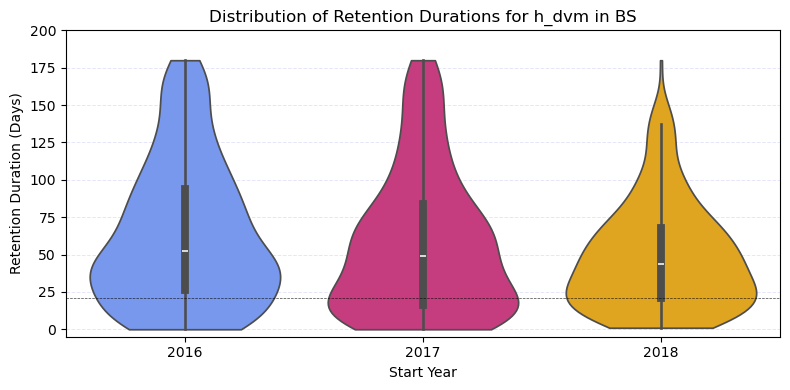

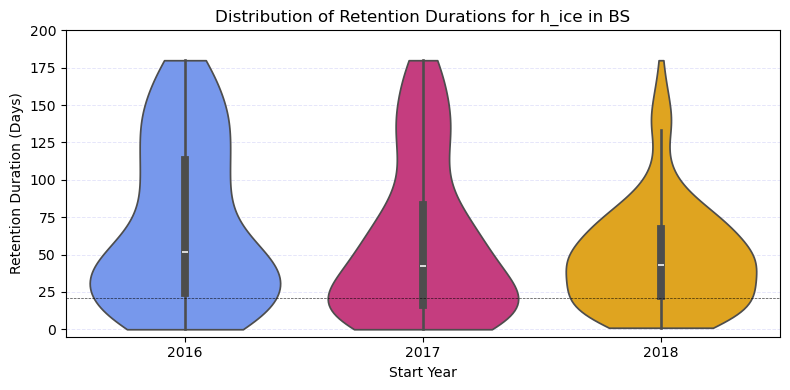

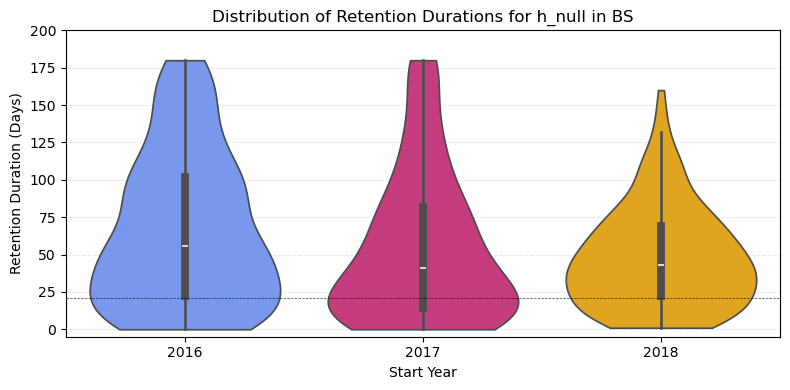

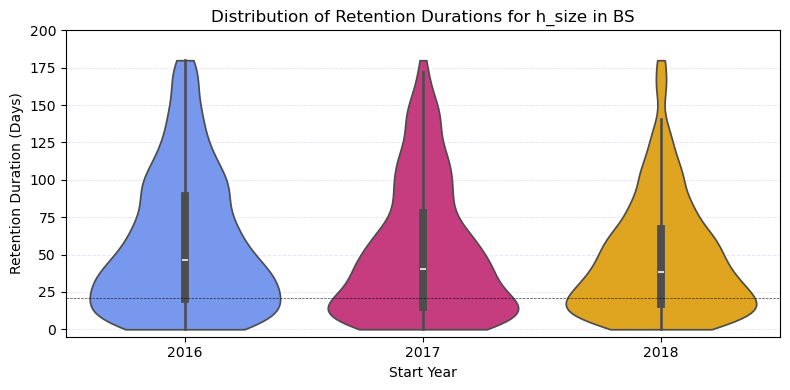

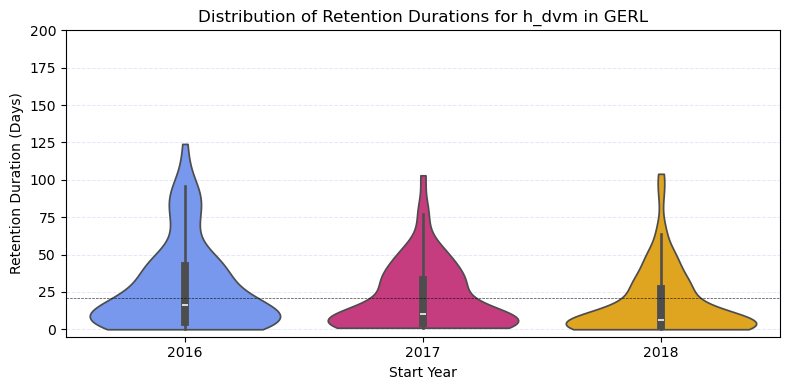

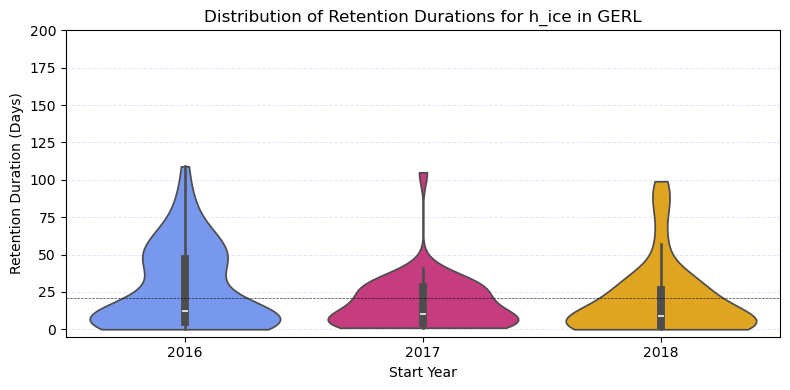

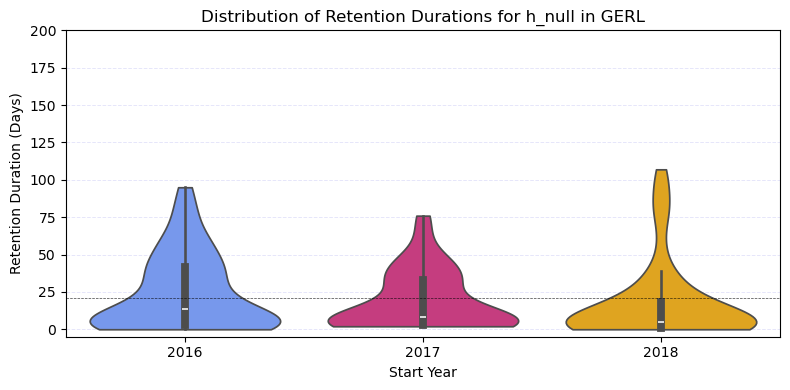

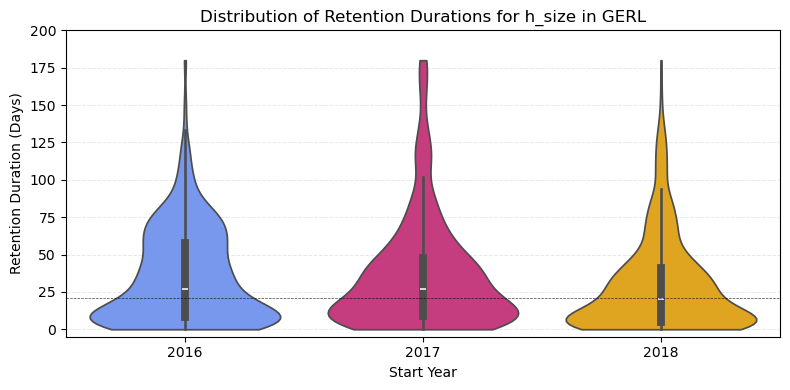

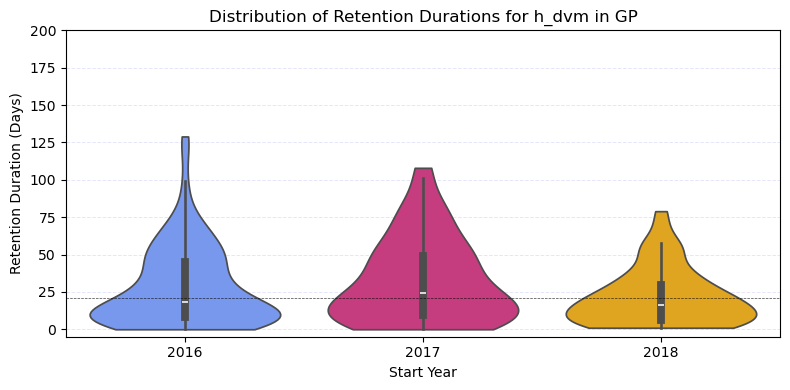

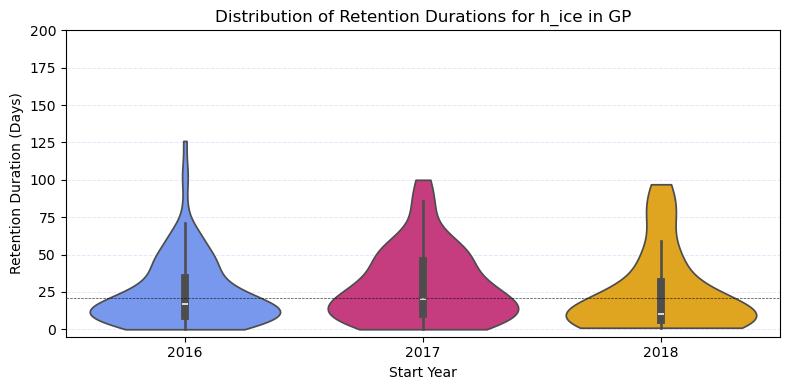

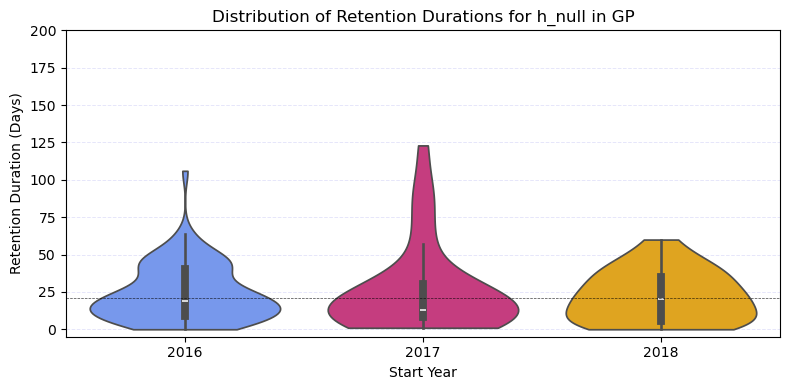

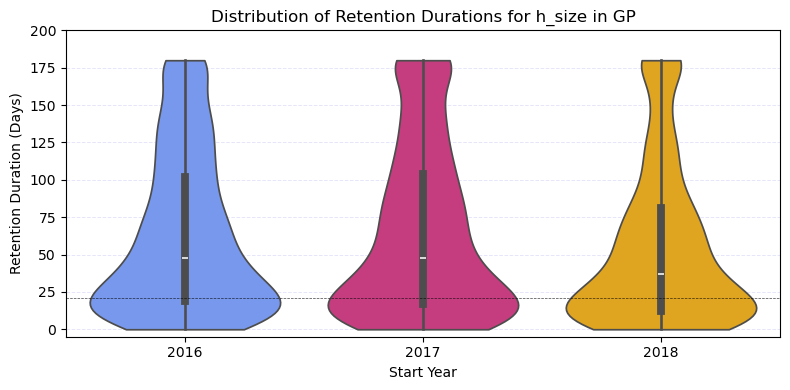

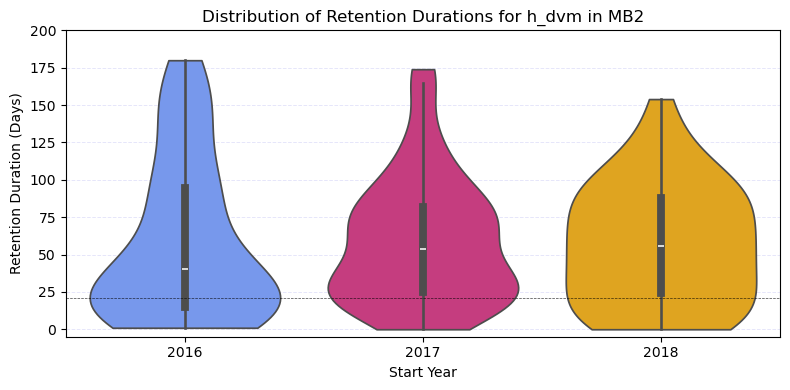

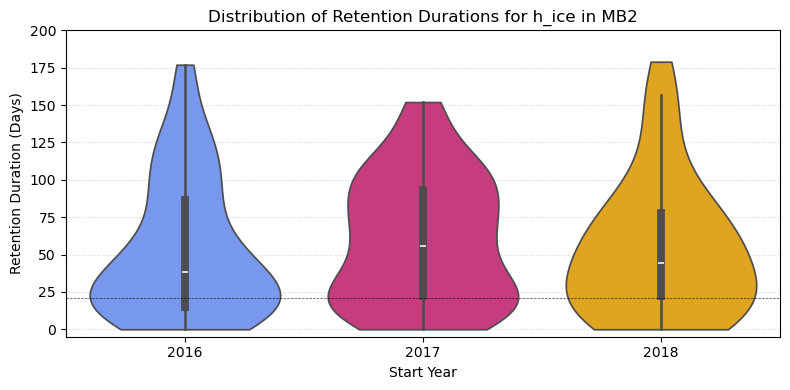

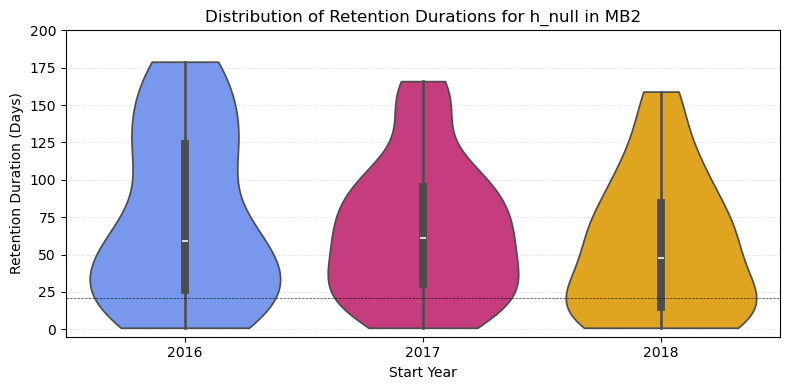

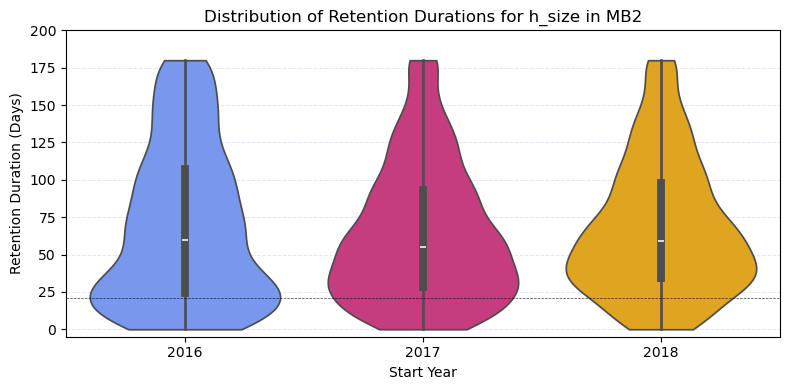

In [10]:
# Loop through all locations and hypotheses, generate, and save plots
locations = ['BS', 'GERL', 'GP', 'MB2']
hypotheses = grouped_df['hypothesis'].unique()

for location in locations:
    for hypothesis in hypotheses:
        plot_distribution_by_year(location, hypothesis)

In [49]:
grouped_df

,hypothesis,start_year,IDL_loc,larval_id,BS,GERL,GP,MB2,outside
0,h_dvm,2016,BS,02_16_1_0001,28,0,0,0,152
1,h_dvm,2016,BS,02_16_1_0002,13,0,0,0,167
2,h_dvm,2016,BS,02_16_1_0003,47,52,0,0,81
3,h_dvm,2016,BS,02_16_1_0004,33,0,0,0,147
4,h_dvm,2016,BS,02_16_1_0005,102,0,0,0,78
...,...,...,...,...,...,...,...,...,...
16653,h_size,2018,MB2,03_18_4_1071,0,0,31,58,91
16654,h_size,2018,MB2,03_18_4_1072,0,0,81,87,12
16655,h_size,2018,MB2,03_18_4_1073,0,0,69,102,9
16656,h_size,2018,MB2,03_18_4_1074,0,0,39,82,59


# Life Stage

In [50]:
processed_df

,N,T,date,lat,lon,release,stage,larval_id,start_year,hypothesis,IDL_loc,BS,GERL,GP,MB2,outside
0,0,0,2016-11-01,-66.912544,287.83374,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
1,0,1,2016-11-02,-66.830450,288.03165,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
2,0,2,2016-11-03,-66.757600,288.15454,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
3,0,3,2016-11-04,-66.711136,288.16013,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
4,0,4,2016-11-05,-66.718590,288.06876,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2998435,199,175,2019-09-12,-60.327457,306.02032,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998436,199,176,2019-09-13,-60.238560,305.90730,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998437,199,177,2019-09-14,-60.116886,305.83090,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998438,199,178,2019-09-15,-60.023293,305.82330,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True


In [51]:
# Group by relevant identifiers and sum the presence counts
grouped_df_ls = processed_df.groupby(
    ['hypothesis', 'start_year', 'IDL_loc', 'larval_id','stage']
)[presence_columns].sum().reset_index()

print('Number of larvae after grouping:', grouped_df_ls.larval_id.nunique())

Number of larvae after grouping: 16658
